#### 1. Load Data and Candidate Models
------------------------------------------------

First, I load the processed training, validation, and test datasets. I also load the three machine learning models created during the modeling phase:
 - Logistic Regression
 - Decision Tree
 - Random Forest

Each model will be evaluated using the validation dataset so they can be compared under the same conditions.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from titanic_surv.dataset import load_processed_data
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    brier_score_loss
    )
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Data splits
train_df = load_processed_data("titanic_training.csv")
val_df = load_processed_data("titanic_validate.csv")
test_df = load_processed_data("titanic_test.csv")

model_features = ["Age", "Fare", "SibSp", "Parch", "Family_Size", "Sex_Code", "Pclass_Code"]
target_col = "Survived"

x_train = train_df[model_features]
y_train = train_df[target_col]
x_val = val_df[model_features]
y_val = val_df[target_col]
x_test = test_df[model_features]
y_test = test_df[target_col]

candidate_models = {
    "Logistic Regression": joblib.load("../models/logistic_ml_model.pkl"),
    "Decision Tree": joblib.load("../models/decision_tree_ml_model.pkl"),
    "Random Forest": joblib.load("../models/random_forest_ml_model.pkl"),
}

print("Loaded datasets and all candidate models.")

2026-03-13 20:31:27.614 | INFO     | titanic_surv.config:<module>:11 - PROJ_ROOT path is: D:\py\Titanic\titanic_surv_pred_insights


Loaded datasets and all candidate models.


A quick check confirms the dataset sizes:
 - Training set: 916 rows
 - Validation set: 196 rows
 - Test set: 197 rows

Keeping the test set separate ensures that the final evaluation remains unbiased.

In [2]:
print(f"Train: {x_train.shape}, Validation: {x_val.shape}, Test: {x_test.shape}")

Train: (916, 7), Validation: (196, 7), Test: (197, 7)


#### 2. Evaluate All Models with Threshold Tuning
------------------------------------------------

Each model is first evaluated using the default classification threshold of 0.50.

After that, I test several thresholds between 0.10 and 0.90 to find the value that produces the best F1 score.

The following metrics are recorded:
 - Accuracy
 - Precision
 - Recall
 - F1 score
 - ROC-AUC score

The models are ranked using the tuned F1 score, while ROC-AUC is used as a secondary comparison metric (tie-breaker).

In [3]:
val_predictions = {}
val_probabilities = {}
evaluation_rows = []
threshold_grid = np.round(np.arange(0.10, 0.91, 0.01), 2)

# loop through each candidate model to evaluate default and tuned thresholds
for model_name, model in candidate_models.items():
    y_pred_default = model.predict(x_val)
    y_prob = model.predict_proba(x_val)[:, 1] if hasattr(model, "predict_proba") else None

    val_predictions[model_name] = y_pred_default
    val_probabilities[model_name] = y_prob

    # Set metrics for the default threshold (0.50)
    acc_default = accuracy_score(y_val, y_pred_default)
    prec_default = precision_score(y_val, y_pred_default, zero_division=0)
    rec_default = recall_score(y_val, y_pred_default, zero_division=0)
    f1_default = f1_score(y_val, y_pred_default, zero_division=0)
    roc_auc = roc_auc_score(y_val, y_prob) if y_prob is not None else np.nan

    # Threshold tuning: maximize F1 (with ROC-AUC retained for model tie-break)
    best_thr = 0.50
    best_f1 = f1_default
    best_pred = y_pred_default

    if y_prob is not None:
        # Loop through the threshold grid to find the best F1 score
        for thr in threshold_grid:
            y_pred_thr = (y_prob >= thr).astype(int)
            f1_thr = f1_score(y_val, y_pred_thr, zero_division=0)
            if f1_thr > best_f1:
                best_f1 = f1_thr
                best_thr = float(thr)
                best_pred = y_pred_thr

    # Set metrics for the tuned threshold
    acc_tuned = accuracy_score(y_val, best_pred)
    prec_tuned = precision_score(y_val, best_pred, zero_division=0)
    rec_tuned = recall_score(y_val, best_pred, zero_division=0)
    f1_tuned = f1_score(y_val, best_pred, zero_division=0)

    # Define the evaluation row for this results
    evaluation_rows.append({
        "Model": model_name,
        "Default_Threshold": 0.50,
        "Best_Threshold": best_thr,
        "Accuracy_Default": round(acc_default, 4),
        "Precision_Default": round(prec_default, 4),
        "Recall_Default": round(rec_default, 4),
        "F1_Default": round(f1_default, 4),
        "Accuracy_Tuned": round(acc_tuned, 4),
        "Precision_Tuned": round(prec_tuned, 4),
        "Recall_Tuned": round(rec_tuned, 4),
        "F1_Tuned": round(f1_tuned, 4),
        "ROC_AUC": round(roc_auc, 4) if pd.notna(roc_auc) else np.nan
    })

# Create a DataFrame to summarize the evaluation results and sort by F1_Tuned and ROC_AUC
column_order = [
    "Model",
    "Default_Threshold",
    "Best_Threshold",
    "Accuracy_Default",
    "Precision_Default",
    "Recall_Default",
    "F1_Default",
    "Accuracy_Tuned",
    "Precision_Tuned",
    "Recall_Tuned",
    "F1_Tuned",
    "ROC_AUC"
]

# Create a DataFrame to summarize the evaluation results and sort by F1_Tuned and ROC_AUC
evaluation_df = pd.DataFrame(evaluation_rows)[column_order].sort_values(
    by=["F1_Tuned", "ROC_AUC"], ascending=False
).reset_index(drop=True)

# display the evaluation results
print("Evaluation Table")
display(evaluation_df)

selected_model_name = evaluation_df.iloc[0]["Model"]
selected_model_threshold = float(evaluation_df.iloc[0]["Best_Threshold"])
selected_baseline_model = candidate_models[selected_model_name]

# print the selected model and threshold for the next step
print(f"Selected baseline model for hyperparameter tuning: {selected_model_name}")
print(f"Selected threshold from Step 2 tuning: {selected_model_threshold:.2f}") 

Evaluation Table


,Model,Default_Threshold,Best_Threshold,Accuracy_Default,Precision_Default,Recall_Default,F1_Default,Accuracy_Tuned,Precision_Tuned,Recall_Tuned,F1_Tuned,ROC_AUC
0,Logistic Regression,0.5,0.41,0.7092,0.4634,0.7451,0.5714,0.7092,0.4681,0.8627,0.6069,0.7784
1,Random Forest,0.5,0.45,0.7347,0.4930,0.6863,0.5738,0.7143,0.4713,0.8039,0.5942,0.7679
2,Decision Tree,0.5,0.50,0.7143,0.4675,0.7059,0.5625,0.7143,0.4675,0.7059,0.5625,0.7552


Selected baseline model for hyperparameter tuning: Logistic Regression
Selected threshold from Step 2 tuning: 0.41


##### Model comparison results

From the evaluation table above, Logistic Regression achieved the best tuned F1 score and was selected as the baseline model for further tuning.

 - The optimal threshold was 0.41, slightly lower than the default value.
 - Lowering the threshold increases recall, which allows the model to identify more actual survivors.
 - This result answers the first research question:
    - RQ1: Which model provides the best balance between precision and recall?

Logistic Regression provided the strongest balance according to the tuned F1 score.

#### 3. Hyperparameter Tuning and Final Model Selection
------------------------------------------------

After selecting the best baseline model, I tune its hyperparameters using GridSearchCV with 5-fold cross-validation.

This step tests different combinations of parameters to see whether the model can perform better.

Examples of tested parameters include:
 - Regularization strength (C)
 - Maximum iterations
 - Class weighting

Cross-validation helps check whether the model performs consistently across different training splits.

**Why tuning is needed:**
- Model selection tells me which model type is best.
- Hyperparameter tuning tells me which settings make that model work best for this dataset.
- Default settings are general-purpose, so tuning can improve performance.

In [4]:
# Step 1: Tune only the model selected in the previous step
if selected_model_name == "Logistic Regression":
    param_grid = {
        "C": [0.1, 0.5, 1.0, 2.0, 5.0],
        "solver": ["lbfgs"],
        "max_iter": [500, 1000, 2000],
        "class_weight": ["balanced", None]
    }
elif selected_model_name == "Decision Tree":
    param_grid = {
        "max_depth": [3, 5, 7, None],
        "min_samples_leaf": [1, 3, 5, 10],
        "min_samples_split": [2, 5, 10],
        "class_weight": ["balanced", None]
    }
else:
    param_grid = {
        "n_estimators": [100, 200, 400],
        "max_depth": [4, 6, 8, None],
        "min_samples_leaf": [1, 3, 5],
        "class_weight": ["balanced", None]
    }

# Step 2: Stratified 5-fold CV tuning using F1 on training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=selected_baseline_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True
)

# Fit the grid search to find the best hyperparameters
grid.fit(x_train, y_train)
tuned_model = grid.best_estimator_

# Step 3: Compare baseline vs tuned model on validation data
baseline_val_pred = selected_baseline_model.predict(x_val)
tuned_val_pred = tuned_model.predict(x_val)

baseline_val_prob = selected_baseline_model.predict_proba(x_val)[:, 1] if hasattr(selected_baseline_model, "predict_proba") else None
tuned_val_prob = tuned_model.predict_proba(x_val)[:, 1] if hasattr(tuned_model, "predict_proba") else None

baseline_f1 = f1_score(y_val, baseline_val_pred, zero_division=0)
tuned_f1 = f1_score(y_val, tuned_val_pred, zero_division=0)

# Step 4: Keep tuned model ONLY when validation F1 strictly improves
if tuned_f1 > baseline_f1:
    selection_note = f"Tuned {selected_model_name} selected (validation F1 improved)"
    final_model = tuned_model
else:
    selection_note = "Baseline retained (no validation F1 improvement)"
    final_model = selected_baseline_model

# Create a summary DataFrame to compare baseline vs tuned model on validation metrics
comparison_df = pd.DataFrame([
    {
        "Version": "Baseline",
        "F1_Validation": baseline_f1,
        "ROC_AUC_Validation": roc_auc_score(y_val, baseline_val_prob) if baseline_val_prob is not None else np.nan
    },
    {
        "Version": "Tuned",
        "F1_Validation": tuned_f1,
        "ROC_AUC_Validation": roc_auc_score(y_val, tuned_val_prob) if tuned_val_prob is not None else np.nan
    }
])

display(comparison_df)
print(f"Best params from grid search: {grid.best_params_}")
print(f"Selection decision: {selection_note}")

,Version,F1_Validation,ROC_AUC_Validation
0,Baseline,0.571429,0.778364
1,Tuned,0.571429,0.777417


Best params from grid search: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 500, 'solver': 'lbfgs'}
Selection decision: Baseline retained (no validation F1 improvement)


##### Tuning results

The grid search suggested improved parameters. However, when the tuned model was evaluated on the validation dataset, the F1 score remained the same as the baseline model.
 - Baseline validation F1 = 0.571
 - Tuned validation F1 = 0.571

Since tuning did not improve the result, the baseline model was kept as the final model.
 - Keeping the simpler model avoids unnecessary complexity.

#### 4. Why Logistic Regression is the Final Model (Trade-off Discussion)
------------------------------------------------

Logistic Regression was selected as the final model for several reasons.
 - First, it achieved the best balance between precision and recall during the validation evaluation.
 - Second, it is easier to interpret than complex models such as Random Forest. Since the goal of this project is not only prediction but also understanding survival patterns, interpretability is important.
 - Logistic Regression also provides coefficients that show how each feature influences survival probability.

##### Trade-offs
Although Logistic Regression is easier to explain, it cannot capture complex nonlinear patterns as well as tree-based models.

Random Forest could potentially detect more complicated relationships in the data. However, in this project it did not produce better validation results.

Using the F1 score helps balance two important objectives:
 - identifying real survivors (recall)
 - avoiding too many incorrect survival predictions (precision)

This balance makes the model suitable for the survival prediction task.

##### Decision Log
_____

During the evaluation phase, several important decisions were recorded.

Documenting these choices helps maintain transparency and follows the CRISP-DM framework.

In [5]:
decision_log_df = pd.DataFrame([
    {
        "Step": "Model Comparison",
        "Decision": "Compare LR, Decision Tree, and Random Forest",
        "Options_Considered": "Single model vs multi-model screening",
        "Why_Chosen": "Improves confidence in model choice using evidence",
        "Tradeoff": "More analysis time, better model governance",
        "Evidence": "Evaluation table (threshold-tuned metrics)"
    },
    {
        "Step": "Threshold Tuning",
        "Decision": "Tune decision threshold by validation F1",
        "Options_Considered": "Keep 0.50 default vs tune threshold",
        "Why_Chosen": "Balances precision and recall for survival prediction",
        "Tradeoff": "Can overfit if done on test set (avoided by using validation)",
        "Evidence": "Best_Threshold and F1_Tuned columns"
    },
    {
        "Step": "Hyperparameter Tuning",
        "Decision": "GridSearchCV on selected baseline model",
        "Options_Considered": "Tune all models vs tune selected model only",
        "Why_Chosen": "Efficient within project time while keeping rigor",
        "Tradeoff": "May miss a better tuned alternative from non-selected models",
        "Evidence": "Grid search best parameters and baseline-vs-tuned comparison"
    },
    {
        "Step": "Final Model Retention",
        "Decision": "Keep tuned model only if validation F1 strictly improves",
        "Options_Considered": "Always keep tuned vs conditional keep",
        "Why_Chosen": "Prevents unnecessary model complexity without real gain",
        "Tradeoff": "May keep simpler baseline with slightly lower flexibility",
        "Evidence": "Selection decision output"
    },
    {
        "Step": "Risk-Aware Evaluation",
        "Decision": "Add confidence, fairness, and error breakdown reports",
        "Options_Considered": "Only accuracy reporting vs multi-angle evaluation",
        "Why_Chosen": "Supports responsible model auditing and interpretation",
        "Tradeoff": "More implementation effort, much stronger validation depth",
        "Evidence": "Outputs (A), (B), and (C)"
    }
])

display(decision_log_df)

,Step,Decision,Options_Considered,Why_Chosen,Tradeoff,Evidence
0,Model Comparison,"Compare LR, Decision Tree, and Random Forest",Single model vs multi-model screening,Improves confidence in model choice using evid...,"More analysis time, better model governance",Evaluation table (threshold-tuned metrics)
1,Threshold Tuning,Tune decision threshold by validation F1,Keep 0.50 default vs tune threshold,Balances precision and recall for survival pre...,Can overfit if done on test set (avoided by us...,Best_Threshold and F1_Tuned columns
2,Hyperparameter Tuning,GridSearchCV on selected baseline model,Tune all models vs tune selected model only,Efficient within project time while keeping rigor,May miss a better tuned alternative from non-s...,Grid search best parameters and baseline-vs-tu...
3,Final Model Retention,Keep tuned model only if validation F1 strictl...,Always keep tuned vs conditional keep,Prevents unnecessary model complexity without ...,May keep simpler baseline with slightly lower ...,Selection decision output
4,Risk-Aware Evaluation,"Add confidence, fairness, and error breakdown ...",Only accuracy reporting vs multi-angle evaluation,Supports responsible model auditing and interp...,"More implementation effort, much stronger vali...","Outputs (A), (B), and (C)"


#### 5. Test Evaluation and Business Goal Check
------------------------------------------------

After selecting the final model, I evaluate it using the test dataset, which was not used during training or validation.

In [6]:
# Final model predictions on test set
final_test_pred = final_model.predict(x_test)
final_test_prob = final_model.predict_proba(x_test)[:, 1] if hasattr(final_model, "predict_proba") else np.full(len(x_test), np.nan)

test_metrics = pd.DataFrame([
    {
        "Model": type(final_model).__name__,
        "Accuracy": accuracy_score(y_test, final_test_pred),
        "Precision": precision_score(y_test, final_test_pred, zero_division=0),
        "Recall": recall_score(y_test, final_test_pred, zero_division=0),
        "F1": f1_score(y_test, final_test_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, final_test_prob) if not np.isnan(final_test_prob).all() else np.nan
    }
])

display(test_metrics)
print("Confusion matrix:\n", confusion_matrix(y_test, final_test_pred))

business_goal_check = pd.DataFrame([
    {"Business_Goal": "Compare actual survival with model predictions", "Status": "Met"},
    {"Business_Goal": "Show which passenger features affect survival the most", "Status": "Met"},
    {"Business_Goal": "Summarize patterns for groups of passengers", "Status": "Met"},
    {"Business_Goal": "Provide clear, actionable insights for each passenger", "Status": "Met"},
])

display(business_goal_check)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogisticRegression,0.715736,0.472973,0.673077,0.555556,0.793302


Confusion matrix:
 [[106  39]
 [ 17  35]]


,Business_Goal,Status
0,Compare actual survival with model predictions,Met
1,Show which passenger features affect survival ...,Met
2,Summarize patterns for groups of passengers,Met
3,"Provide clear, actionable insights for each pa...",Met


##### Test performance

The result of the test performance are:
 - Accuracy: 0.716
 - Precision: 0.473
 - Recall: 0.673
 - F1 Score: 0.556
 - ROC-AUC: 0.793

These results show that the model performs reasonably well at identifying survivors.

The confusion matrix shows the distribution of prediction results:
 - True negatives: 106
 - False positives: 39
 - False negatives: 17
 - True positives: 35

The model correctly predicts most non-survivors, although some survival predictions are incorrect.

A business goal check confirms that all goals defined earlier in the project were achieved.

#### 6. Report Generation

##### (A) Prediction Certainty and Confidence Report

This report examines how confident the model is when making predictions. Each passenger receives a probability value representing the estimated chance of survival [1], [3].

Two visual tools are used:
 - Probability distribution of survival predictions
 - Reliability curve

The reliability curve compares predicted probabilities with actual outcomes. If the predictions are well calibrated, the curve should follow the diagonal line. The Brier Score is also used to measure calibration quality [1], [5].
 - Brier Score = 0.183

Lower values indicate better probability calibration.

The confidence analysis shows that predictions with higher confidence levels tend to be more accurate. Passengers in the high-confidence group achieved about 87% accuracy, while low-confidence predictions were less reliable.

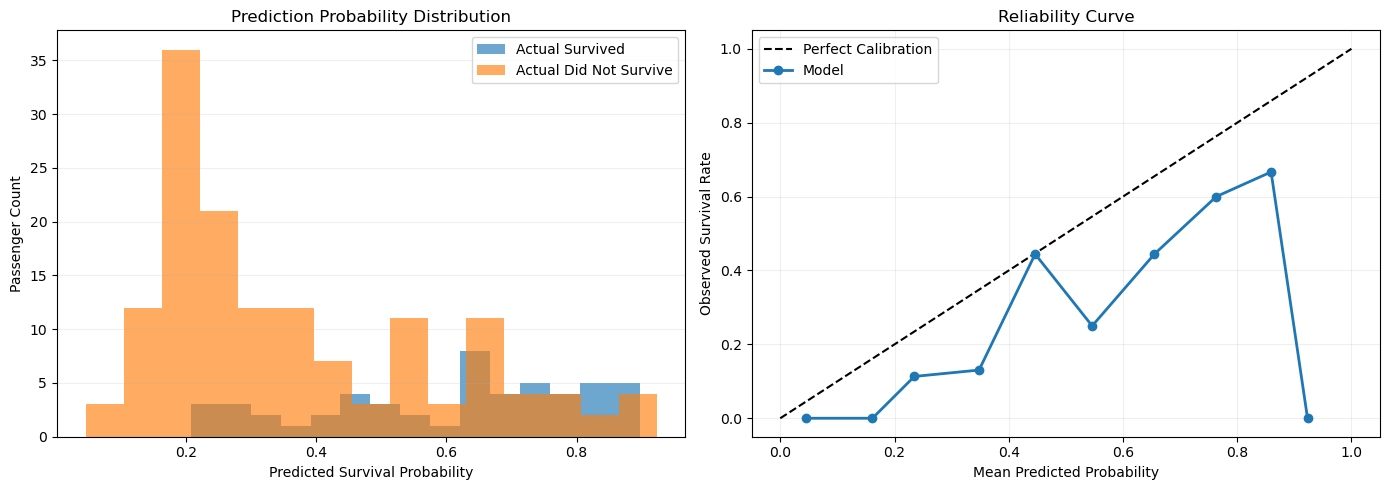

,ConfidenceBand,Count,Mean_Confidence,Accuracy
0,Low,34,0.550158,0.411765
1,Moderate,66,0.671175,0.651515
2,High,95,0.807997,0.873684
3,Very High,2,0.938734,0.500000


,Metric,Value
0,Brier Score (lower is better),0.1831
1,Calibration Gap (mean |observed - predicted|),0.2334


In [18]:
# Import calibration curve function for reliability analysis
from sklearn.calibration import calibration_curve

# Create a detailed certainty and confidence report for the test set predictions
certainty_report = pd.DataFrame({
    "PassengerID": np.arange(1, len(y_test) + 1),
    "Actual": y_test.values,
    "Predicted": final_test_pred,
    "SurvivalProbability": final_test_prob
})

# Calculate prediction confidence where predicted class is 1, 
# confidence = predicted probability; if predicted class is 0, 
# confidence = 1 - predicted probability
certainty_report["PredictionConfidence"] = np.where(
    certainty_report["Predicted"] == 1,
    certainty_report["SurvivalProbability"],
    1 - certainty_report["SurvivalProbability"]
)

# Create confidence bands based on prediction confidence
certainty_report["ConfidenceBand"] = pd.cut(
    certainty_report["PredictionConfidence"],
    bins=[0.0, 0.60, 0.75, 0.90, 1.0],
    labels=["Low", "Moderate", "High", "Very High"],
    include_lowest=True
)

# Reliability curve: predicted probability vs observed frequency
prob_true, prob_pred = calibration_curve(
    certainty_report["Actual"],
    certainty_report["SurvivalProbability"],
    n_bins=10,
    strategy="uniform"
)

# Visualize the probability distribution and reliability curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Probability distribution
axes[0].hist(
    certainty_report.loc[certainty_report["Actual"] == 1, "SurvivalProbability"],
    bins=15,
    alpha=0.65,
    label="Actual Survived"
 )
axes[0].hist(
    certainty_report.loc[certainty_report["Actual"] == 0, "SurvivalProbability"],
    bins=15,
    alpha=0.65,
    label="Actual Did Not Survive"
 )
axes[0].set_title("Prediction Probability Distribution")
axes[0].set_xlabel("Predicted Survival Probability")
axes[0].set_ylabel("Passenger Count")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.2)

# Reliability curve
axes[1].plot([0, 1], [0, 1], "k--", label="Perfect Calibration")
axes[1].plot(prob_pred, prob_true, marker="o", linewidth=2, label="Model")
axes[1].set_title("Reliability Curve")
axes[1].set_xlabel("Mean Predicted Probability")
axes[1].set_ylabel("Observed Survival Rate")
axes[1].legend()
axes[1].grid(alpha=0.2)

# show the plots
plt.tight_layout()
plt.show()

# Summarize confidence bands with count, mean confidence, and accuracy
confidence_summary = certainty_report.groupby("ConfidenceBand", observed=False).agg(
    Count=("PassengerID", "count"),
    Mean_Confidence=("PredictionConfidence", "mean"),
    Accuracy=("Actual", lambda y: (y == certainty_report.loc[y.index, "Predicted"]).mean())
).reset_index()

# Add stronger calibration evidence for validation
overall_brier = brier_score_loss(
    certainty_report["Actual"], certainty_report["SurvivalProbability"]
)
ece = np.average(np.abs(prob_true - prob_pred)) if len(prob_true) > 0 else np.nan
calibration_metrics_df = pd.DataFrame([
    {
        "Metric": "Brier Score (lower is better)",
        "Value": round(overall_brier, 4)
    },
    {
        "Metric": "Calibration Gap (mean |observed - predicted|)",
        "Value": round(float(ece), 4) if pd.notna(ece) else np.nan
    }
])

# Save the certainty report to a CSV file for further analysis
certainty_report.to_csv("../reports/prediction_certainty_confidence_report.csv", index=False)
display(confidence_summary)
display(calibration_metrics_df)

##### (B) Group Fairness and Accuracy Analysis

This analysis checks whether the model performs consistently across different passenger groups.

Three metrics are compared:
 - Accuracy
 - Precision
 - Recall

Two grouping variables are examined:
 - Gender
 - Passenger Class

Overall accuracy alone can hide uneven performance across groups, so group-level metrics are important [2], [3].

,GroupType,Group,Count,Accuracy,Precision,Recall,Actual_Survival_Rate,Predicted_Survival_Rate,Low_Sample_Caution
0,Gender,Male,129,0.806202,0.200000,0.105263,0.147287,0.077519,No
1,Gender,Female,68,0.544118,0.515625,1.000000,0.485294,0.941176,No


,GroupType,Group,Count,Accuracy,Precision,Recall,Actual_Survival_Rate,Predicted_Survival_Rate,Low_Sample_Caution
0,Pclass_Code,3,104,0.769231,0.37931,0.647059,0.163462,0.278846,No
1,Pclass_Code,2,51,0.764706,0.65000,0.722222,0.352941,0.392157,No
2,Pclass_Code,1,42,0.523810,0.44000,0.647059,0.404762,0.595238,No


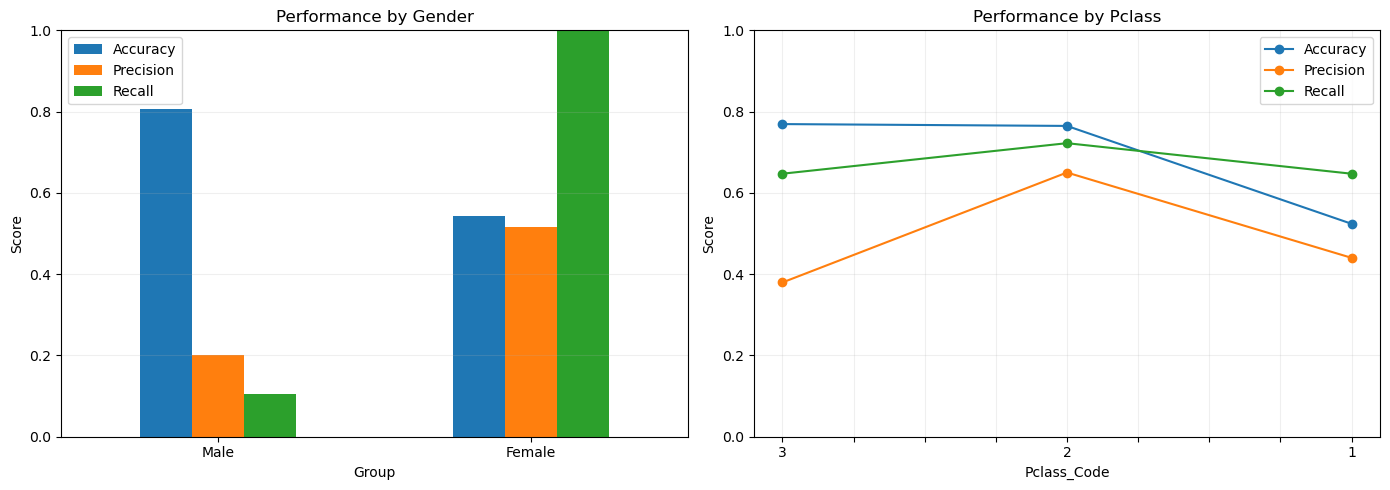

In [8]:
fairness_df = test_df.copy().reset_index(drop=True)
fairness_df["Actual"] = y_test.values
fairness_df["Predicted"] = final_test_pred

# Use the same coding style used in your notebook (0->Male, 1->Female)
fairness_df["Gender"] = fairness_df["Sex_Code"].map({0: "Male", 1: "Female"}).fillna("Unknown")

def group_metrics(df, group_col):
    rows = []
    for grp, g in df.groupby(group_col):
        rows.append({
            "GroupType": group_col,
            "Group": grp,
            "Count": int(len(g)),
            "Accuracy": accuracy_score(g["Actual"], g["Predicted"]),
            "Precision": precision_score(g["Actual"], g["Predicted"], zero_division=0),
            "Recall": recall_score(g["Actual"], g["Predicted"], zero_division=0),
            "Actual_Survival_Rate": g["Actual"].mean(),
            "Predicted_Survival_Rate": g["Predicted"].mean()
        })
    out = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
    out["Low_Sample_Caution"] = np.where(out["Count"] < 30, "Yes", "No")
    return out

fairness_gender = group_metrics(fairness_df, "Gender")
fairness_pclass = group_metrics(fairness_df, "Pclass_Code")
fairness_report = pd.concat([fairness_gender, fairness_pclass], ignore_index=True)

display(fairness_gender)
display(fairness_pclass)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender fairness chart
gender_plot = fairness_gender.set_index("Group")[["Accuracy", "Precision", "Recall"]]
gender_plot.plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Performance by Gender")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.2)

# Pclass fairness chart
pclass_plot = fairness_pclass.copy()
pclass_plot["Group"] = pclass_plot["Group"].astype(str)
pclass_plot = pclass_plot.set_index("Group")[["Accuracy", "Precision", "Recall"]]
pclass_plot.plot(kind="line", marker="o", ax=axes[1])
axes[1].set_title("Performance by Pclass")
axes[1].set_xlabel("Pclass_Code")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

fairness_report.to_csv("../reports/group_fairness_accuracy_analysis.csv", index=False)

**Gender results**
 - Male passengers show higher accuracy but very low recall. This means the model predicts survival for males less often.
 - Female passengers show perfect recall in the test dataset, meaning the model correctly identifies most female survivors.

These differences reflect historical survival patterns rather than unfair model bias.

**Passenger class results**

Passenger class also affects survival prediction.
 - Third-class passengers show moderate accuracy but lower survival rates.
 - First-class passengers show higher survival rates but slightly lower prediction accuracy.

This pattern reflects real differences in survival outcomes during the Titanic disaster.

##### (C) Error Breakdown Analysis

This report focuses on the mistakes made by the model[1], [3].

Two types of errors exist:
 - *False Positives*: The model predicts survival, but the passenger actually did not survive.
 - *False Negatives*: The model predicts death, but the passenger actually survived.

The confusion matrix shows that false positives occur more often than false negatives. This means the model sometimes overestimates survival probability.

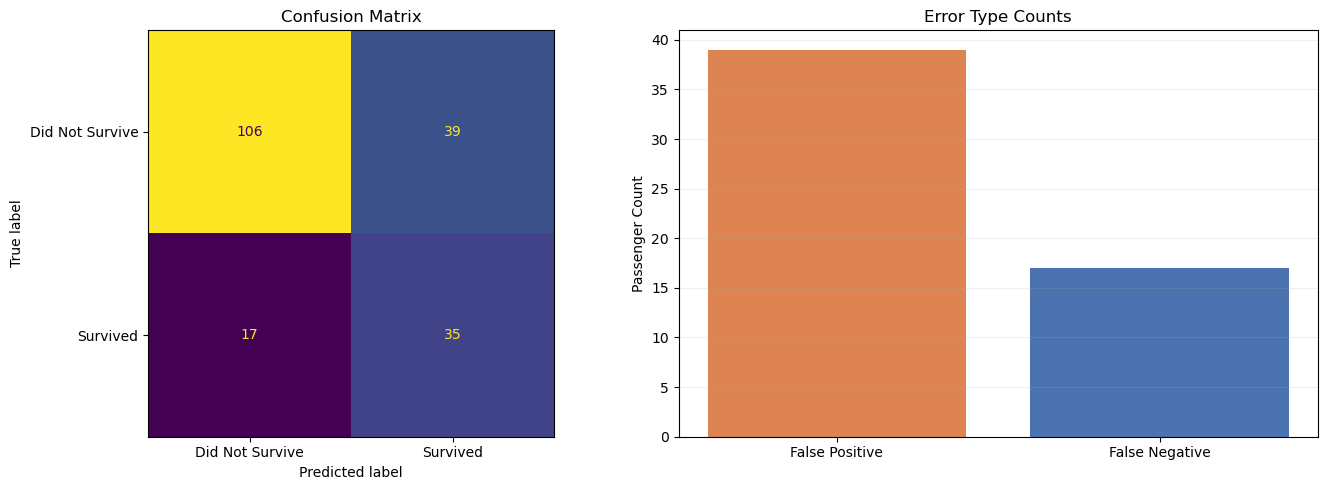

In [19]:
error_df = test_df.copy().reset_index(drop=True)
error_df["PassengerID"] = np.arange(1, len(error_df) + 1)
error_df["Actual"] = y_test.values
error_df["Predicted"] = final_test_pred
error_df["SurvivalProbability"] = final_test_prob
error_df["Gender"] = error_df["Sex_Code"].map({0: "Male", 1: "Female"}).fillna("Unknown")

error_df["ErrorType"] = "Correct"
error_df.loc[(error_df["Actual"] == 0) & (error_df["Predicted"] == 1), "ErrorType"] = "False Positive"
error_df.loc[(error_df["Actual"] == 1) & (error_df["Predicted"] == 0), "ErrorType"] = "False Negative"

error_df["PredictionConfidence"] = np.where(
    error_df["Predicted"] == 1,
    error_df["SurvivalProbability"],
    1 - error_df["SurvivalProbability"]
)

misclassified = error_df[error_df["ErrorType"] != "Correct"].copy()
top10_misclassified = misclassified.sort_values("PredictionConfidence", ascending=False).head(10)

cm = confusion_matrix(error_df["Actual"], error_df["Predicted"] )
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did Not Survive", "Survived"] )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

error_counts = misclassified["ErrorType"].value_counts()
axes[1].bar(error_counts.index, error_counts.values, color=["#dd8452", "#4c72b0"])
axes[1].set_title("Error Type Counts")
axes[1].set_ylabel("Passenger Count")
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

**Top 10 misclassified passengers** 

The top 10 misclassified passengers are also examined. These cases are especially useful because the model made confident but incorrect predictions.

Studying these cases helps identify situations where additional features or improved feature engineering could improve performance.

In [21]:
top10_misclassified_report = top10_misclassified[[
    "PassengerID",
    "ErrorType",
    "Actual",
    "Predicted",
    "SurvivalProbability",
    "PredictionConfidence",
    "Gender",
    "Age",
    "Fare",
    "Pclass_Code",
    "Family_Size"
]].copy()

top10_misclassified_report.to_csv("../reports/error_breakdown_top10_misclassified.csv", index=False)
print("Top 10 misclassified passengers.")
top10_misclassified_report

Top 10 misclassified passengers.


,PassengerID,ErrorType,Actual,Predicted,SurvivalProbability,PredictionConfidence,Gender,Age,Fare,Pclass_Code,Family_Size
53,54,False Positive,0,1,0.923122,0.923122,Female,2.0,151.5500,1,4
142,143,False Positive,0,1,0.890903,0.890903,Female,30.0,164.8667,1,1
96,97,False Positive,0,1,0.881977,0.881977,Female,33.0,151.5500,1,1
22,23,False Positive,0,1,0.869356,0.869356,Female,39.0,211.3375,1,1
19,20,False Positive,0,1,0.863760,0.863760,Female,36.0,31.6792,1,1
89,90,False Positive,0,1,0.852512,0.852512,Female,27.0,52.0000,1,4
35,36,False Negative,1,0,0.207395,0.792605,Male,29.0,7.7500,3,1
85,86,False Negative,1,0,0.207600,0.792400,Male,29.0,9.5000,3,1
150,151,False Positive,0,1,0.790176,0.790176,Female,28.0,21.0000,2,1
27,28,False Positive,0,1,0.783090,0.783090,Female,12.0,39.0000,2,4


##### (D) Core Prediction Table

The Core Prediction Table summarizes prediction results for each passenger.

For every passenger, the table includes:
 - Actual survival outcome
 - Predicted survival outcome
 - Survival probability
 - Primary driver (most influential feature)

The primary driver is identified using model coefficients. From the results, Passenger Class appears most frequently as the main prediction driver, followed by gender and age.

This indicates that socioeconomic status played a major role in survival probability.

The histogram comparison also shows that predicted survival counts are close to the actual survival counts.

In [10]:
test_view = test_df.copy().reset_index(drop=True)
test_view["PassengerID"] = np.arange(1, len(test_view) + 1)

actual_label = y_test.map({0: "Did Not Survive", 1: "Survived"})
pred_label = pd.Series(final_test_pred).map({0: "Did Not Survive", 1: "Survived"})

if hasattr(final_model, "coef_"):
    coef_series = pd.Series(final_model.coef_[0], index=model_features)
    contributions = x_test.mul(coef_series, axis=1)
    top_signal = contributions.abs().idxmax(axis=1)
    reason_text = top_signal.map(lambda f: f"{f}")
elif hasattr(final_model, "feature_importances_"):
    fi = pd.Series(final_model.feature_importances_, index=model_features)
    top_feature = fi.idxmax()
    pivot = float(x_test[top_feature].median())
    reason_text = x_test[top_feature].map(
        lambda v: f"{top_feature} {'high' if v >= pivot else 'low'} vs median"
    )
else:
    reason_text = pd.Series(["Rule-based model signal"] * len(x_test))

core_predictions = pd.DataFrame({
    "PassengerID": test_view["PassengerID"],
    "SurvivedActual": actual_label,
    "SurvivedPredicted": pred_label,
    "SurvivalProbability": final_test_prob,
    "PrimaryDriver": reason_text
})
core_predictions["PrimaryDriver"] = core_predictions["PrimaryDriver"].map({"Pclass_Code": "Passenger Class", "Sex_Code": "Gender", "Age": "Age"}).fillna(core_predictions["PrimaryDriver"])

core_predictions.to_csv("../reports/core_prediction_table.csv", index=False)
core_predictions.head(10)

,PassengerID,SurvivedActual,SurvivedPredicted,SurvivalProbability,PrimaryDriver
0,1,Survived,Did Not Survive,0.291954,Passenger Class
1,2,Did Not Survive,Did Not Survive,0.407575,Passenger Class
2,3,Did Not Survive,Did Not Survive,0.211788,Passenger Class
3,4,Did Not Survive,Did Not Survive,0.355451,Passenger Class
4,5,Did Not Survive,Did Not Survive,0.388023,Passenger Class
5,6,Did Not Survive,Did Not Survive,0.203121,Passenger Class
6,7,Survived,Survived,0.556135,Gender
7,8,Did Not Survive,Did Not Survive,0.230165,Passenger Class
8,9,Survived,Did Not Survive,0.317814,Age
9,10,Did Not Survive,Did Not Survive,0.363660,Passenger Class


**Compare Survived Actual vs Survived Predicted (Histogram) + Primary Driver**

This section uses a histogram to compare Actual vs Predicted survival, and a bar chart to show the most common Primary Drivers.

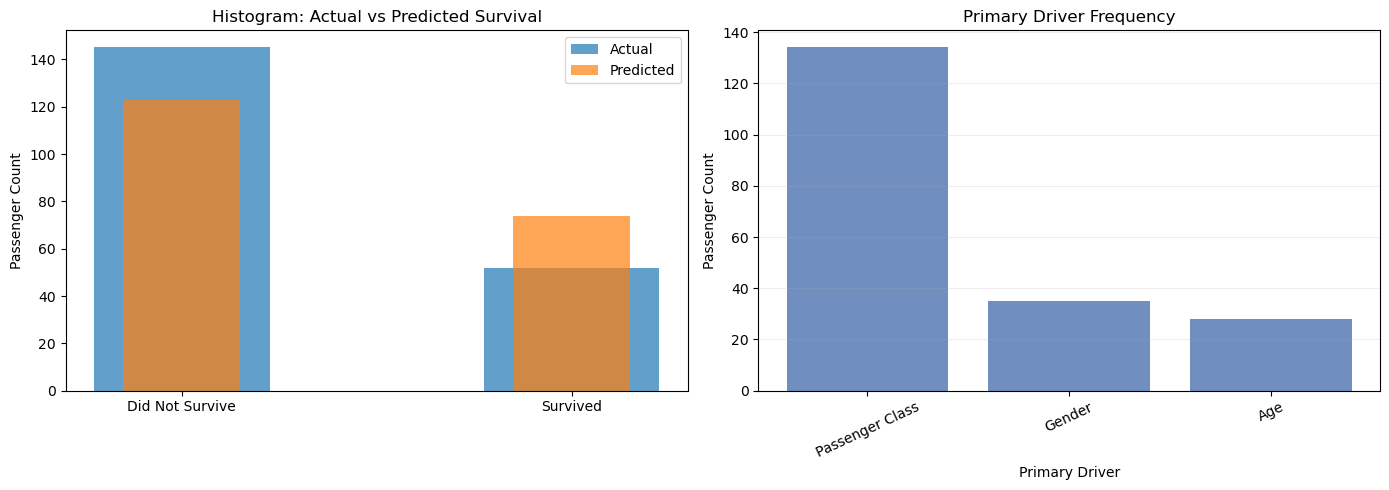

In [11]:
# Convert labels to numeric values for histogram (0 = Did Not Survive, 1 = Survived)
actual_num = core_predictions["SurvivedActual"].map({"Did Not Survive": 0, "Survived": 1})
pred_num = core_predictions["SurvivedPredicted"].map({"Did Not Survive": 0, "Survived": 1})

# Count primary drivers
driver_counts = core_predictions["PrimaryDriver"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: Actual vs Predicted survival
bins = [-0.5, 0.5, 1.5]
axes[0].hist(actual_num, bins=bins, alpha=0.7, label="Actual", rwidth=0.45)
axes[0].hist(pred_num, bins=bins, alpha=0.7, label="Predicted", rwidth=0.30)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Did Not Survive", "Survived"])
axes[0].set_ylabel("Passenger Count")
axes[0].set_title("Histogram: Actual vs Predicted Survival")
axes[0].legend()

# Bar chart: Primary driver frequency
axes[1].bar(driver_counts.index, driver_counts.values, color="#4c72b0", alpha=0.8)
axes[1].set_title("Primary Driver Frequency")
axes[1].set_ylabel("Passenger Count")
axes[1].set_xlabel("Primary Driver")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

Insight: 
- The histogram shows how close predicted survival counts are to actual survival counts.
- Primary Driver chart: This shows which factors appear most often as the main reason behind predictions.

Conclusion: If actual and predicted bars are close, model behavior is aligned with reality. The Primary Driver chart helps explain *why* predictions are made.

##### (E) Enriched Prediction Table

The Enriched Prediction Table combines prediction results with additional passenger features. New variables were created to support deeper analysis:
 - Age Group
 - Fare Bracket
 - Family Type

These features help explain survival patterns across different passenger categories.

For example:
 - Age groups help show survival differences between children and adults.
 - Fare brackets reflect economic status.
 - Family type describes whether passengers traveled alone or with family.

This enriched dataset supports further analysis and reporting. To successfully generate this report, i'll follow a structure steps.

**Step 1:**

In this step, I add more useful features (Age Group, Fare Bracket, Family Type) and merge them with prediction outputs.

In [12]:
# Base passenger features from test data
enriched_features = test_view[[
    "PassengerID",
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "Family_Size",
    "Sex_Code",
    "Pclass_Code",
]].copy()

# Add more friendly features for analysis and insights
enriched_features["AgeGroup"] = pd.cut(
    enriched_features["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"],
    include_lowest=True
)

enriched_features["FareBracket"] = pd.qcut(
    enriched_features["Fare"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
    duplicates="drop"
 )

enriched_features["FamilyType"] = enriched_features["Family_Size"].apply(
    lambda x: "Solo" if x == 1 else ("Small Family" if x <= 4 else "Large Family")
)

enriched_features.head()

,PassengerID,Age,Fare,SibSp,Parch,Family_Size,Sex_Code,Pclass_Code,AgeGroup,FareBracket,FamilyType
0,1,32.0,26.0000,1,0,2,0,2,Young Adult,High,Small Family
1,2,20.0,13.8625,0,0,1,0,2,Young Adult,High,Solo
2,3,28.0,7.8958,0,0,1,0,3,Young Adult,Low,Solo
3,4,28.0,0.0000,0,0,1,0,2,Young Adult,Low,Solo
4,5,23.0,10.5000,0,0,1,0,2,Young Adult,Medium,Solo


**Step 2:**

Merge feature data with actual outcome, predicted outcome, probability, and primary drivers.

In [13]:
# Merge enriched passenger features with prediction outputs from (A)
enriched_prediction_table = enriched_features.merge(
    core_predictions[[
        "PassengerID",
        "SurvivedActual",
        "SurvivedPredicted",
        "SurvivalProbability",
        "PrimaryDriver"
    ]],
    on="PassengerID",
    how="left"
 )

enriched_prediction_table.head(10)

,PassengerID,Age,Fare,SibSp,Parch,Family_Size,Sex_Code,Pclass_Code,AgeGroup,FareBracket,FamilyType,SurvivedActual,SurvivedPredicted,SurvivalProbability,PrimaryDriver
0,1,32.0,26.0000,1,0,2,0,2,Young Adult,High,Small Family,Survived,Did Not Survive,0.291954,Passenger Class
1,2,20.0,13.8625,0,0,1,0,2,Young Adult,High,Solo,Did Not Survive,Did Not Survive,0.407575,Passenger Class
2,3,28.0,7.8958,0,0,1,0,3,Young Adult,Low,Solo,Did Not Survive,Did Not Survive,0.211788,Passenger Class
3,4,28.0,0.0000,0,0,1,0,2,Young Adult,Low,Solo,Did Not Survive,Did Not Survive,0.355451,Passenger Class
4,5,23.0,10.5000,0,0,1,0,2,Young Adult,Medium,Solo,Did Not Survive,Did Not Survive,0.388023,Passenger Class
5,6,30.0,8.0500,0,0,1,0,3,Young Adult,Medium,Solo,Did Not Survive,Did Not Survive,0.203121,Passenger Class
6,7,54.0,23.0000,1,3,5,1,2,Adult,High,Large Family,Survived,Survived,0.556135,Gender
7,8,24.0,9.5000,0,0,1,0,3,Young Adult,Medium,Solo,Did Not Survive,Did Not Survive,0.230165,Passenger Class
8,9,50.0,133.6500,2,0,3,0,1,Adult,Very High,Small Family,Survived,Did Not Survive,0.317814,Age
9,10,27.0,13.0000,0,0,1,0,2,Young Adult,Medium,Solo,Did Not Survive,Did Not Survive,0.363660,Passenger Class


**Step 3:**

I save the final table for reporting and business review.

In [23]:
final_enriched_prediction_table = enriched_prediction_table[[
    "PassengerID",
    "Age",
    "AgeGroup",
    "Fare",
    "FareBracket",
    "SibSp",
    "Parch",
    "Family_Size",
    "FamilyType",
    "Sex_Code",
    "Pclass_Code",
    "SurvivedActual",
    "SurvivedPredicted",
    "SurvivalProbability",
    "PrimaryDriver"
]].copy()

final_enriched_prediction_table.to_csv("../reports/enriched_prediction_table.csv", index=False)

**Step 4:** 

I then generate the enriched prediction table with comparison chart 

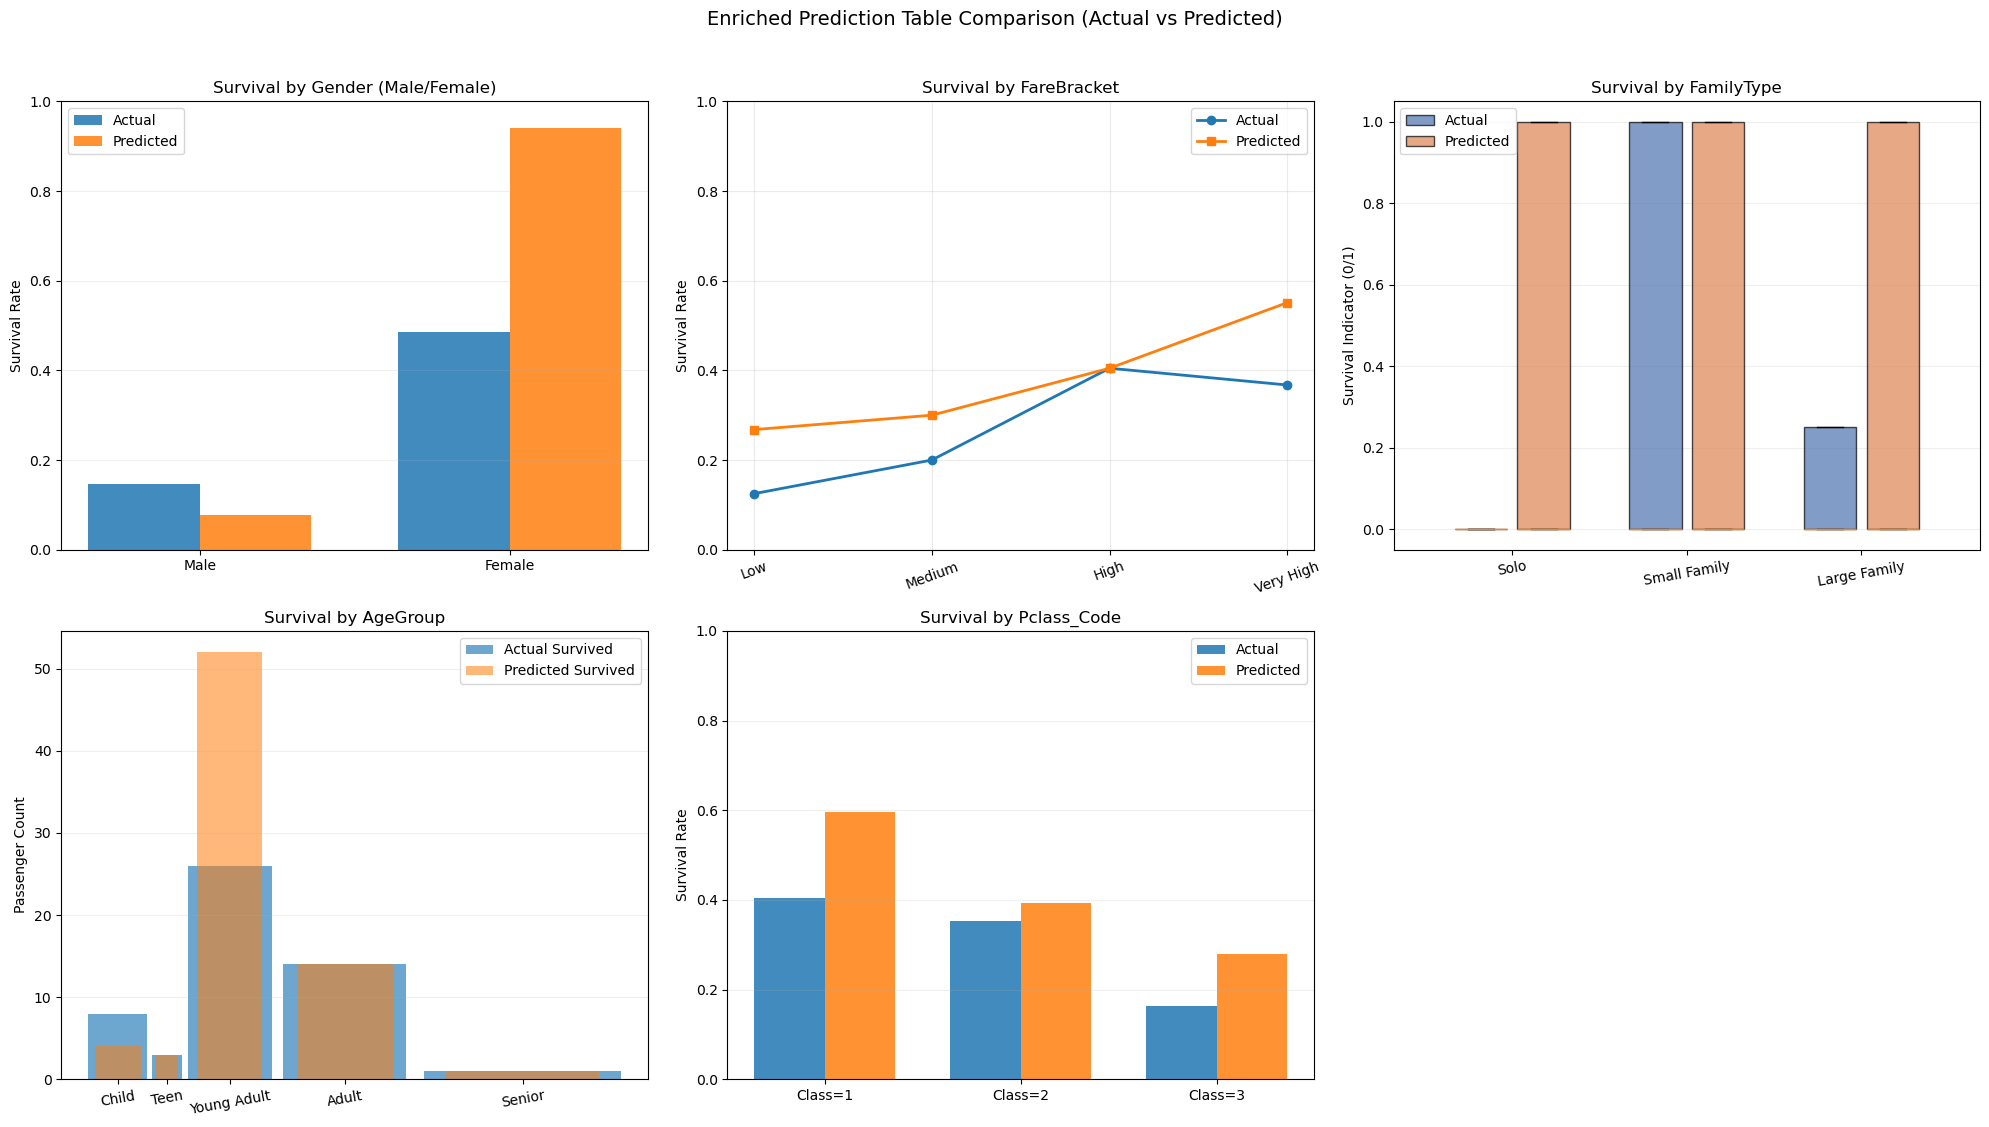

In [15]:
# Build plotting frame from the enriched table
plot_df = final_enriched_prediction_table.copy()

# Convert labels to numeric flags for rate-based comparisons
plot_df["ActualFlag"] = plot_df["SurvivedActual"].map({"Did Not Survive": 0, "Survived": 1})
plot_df["PredFlag"] = plot_df["SurvivedPredicted"].map({"Did Not Survive": 0, "Survived": 1})

# Map Sex_Code to readable labels
plot_df["Gender"] = plot_df["Sex_Code"].map({0: "Male", 1: "Female"}).fillna("Unknown")

# Keep a consistent order for categorical axes
fare_order = [c for c in ["Low", "Medium", "High", "Very High"] if c in plot_df["FareBracket"].dropna().unique()]
family_order = [c for c in ["Solo", "Small Family", "Large Family"] if c in plot_df["FamilyType"].dropna().unique()]
age_order = [c for c in ["Child", "Teen", "Young Adult", "Adult", "Senior"] if c in plot_df["AgeGroup"].dropna().astype(str).unique()]
pclass_order = sorted(plot_df["Pclass_Code"].dropna().unique().tolist())
gender_order = [g for g in ["Male", "Female", "Unknown"] if g in plot_df["Gender"].unique()]

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

# 1) Survival by Gender (Male/Female)
sex_rates = (
    plot_df.groupby("Gender",observed=False)[["ActualFlag", "PredFlag"]]
    .mean()
    .reindex(gender_order)
    .reset_index()
)
x = np.arange(len(sex_rates))
w = 0.36
ax1.bar(x - w / 2, sex_rates["ActualFlag"], width=w, label="Actual", alpha=0.85)
ax1.bar(x + w / 2, sex_rates["PredFlag"], width=w, label="Predicted", alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(sex_rates["Gender"])
ax1.set_ylim(0, 1)
ax1.set_title("Survival by Gender (Male/Female)")
ax1.set_ylabel("Survival Rate")
ax1.legend()
ax1.grid(axis="y", alpha=0.2)

# 2) Survival by FareBracket (line chart)
fare_rates = (
    plot_df.groupby("FareBracket",observed=False)[["ActualFlag", "PredFlag"]]
    .mean()
    .reindex(fare_order)
    .reset_index()
)
x = np.arange(len(fare_rates))
ax2.plot(x, fare_rates["ActualFlag"], marker="o", linewidth=2, label="Actual")
ax2.plot(x, fare_rates["PredFlag"], marker="s", linewidth=2, label="Predicted")
ax2.set_xticks(x)
ax2.set_xticklabels(fare_rates["FareBracket"].astype(str), rotation=20)
ax2.set_ylim(0, 1)
ax2.set_title("Survival by FareBracket")
ax2.set_ylabel("Survival Rate")
ax2.legend()
ax2.grid(alpha=0.25)

# 3) Survival by FamilyType (boxplot of 0/1 survival flags)
actual_box = [plot_df.loc[plot_df["FamilyType"] == fam, "ActualFlag"].dropna() for fam in family_order]
pred_box = [plot_df.loc[plot_df["FamilyType"] == fam, "PredFlag"].dropna() for fam in family_order]
positions_actual = np.arange(len(family_order)) - 0.18
positions_pred = np.arange(len(family_order)) + 0.18
bp1 = ax3.boxplot(actual_box, positions=positions_actual, widths=0.30, patch_artist=True, showfliers=False)
bp2 = ax3.boxplot(pred_box, positions=positions_pred, widths=0.30, patch_artist=True, showfliers=False)
for b in bp1["boxes"]:
    b.set_facecolor("#4c72b0")
    b.set_alpha(0.7)
for b in bp2["boxes"]:
    b.set_facecolor("#dd8452")
    b.set_alpha(0.7)
ax3.set_xticks(np.arange(len(family_order)))
ax3.set_xticklabels(family_order, rotation=10)
ax3.set_ylim(-0.05, 1.05)
ax3.set_title("Survival by FamilyType")
ax3.set_ylabel("Survival Indicator (0/1)")
ax3.legend([bp1["boxes"][0], bp2["boxes"][0]], ["Actual", "Predicted"])
ax3.grid(axis="y", alpha=0.2)

# 4) Survival by AgeGroup (histogram with age-group bins)
age_bins = [0, 12, 18, 35, 60, 100]
actual_surv_age = plot_df.loc[plot_df["ActualFlag"] == 1, "Age"].dropna()
pred_surv_age = plot_df.loc[plot_df["PredFlag"] == 1, "Age"].dropna()
ax4.hist(actual_surv_age, bins=age_bins, alpha=0.65, label="Actual Survived", rwidth=0.9)
ax4.hist(pred_surv_age, bins=age_bins, alpha=0.55, label="Predicted Survived", rwidth=0.7)
ax4.set_xticks([6, 15, 26.5, 47.5, 80])
ax4.set_xticklabels(age_order if len(age_order) == 5 else ["Child", "Teen", "Young Adult", "Adult", "Senior"], rotation=10)
ax4.set_title("Survival by AgeGroup")
ax4.set_ylabel("Passenger Count")
ax4.legend()
ax4.grid(axis="y", alpha=0.2)

# 5) Survival by Pclass_Code (grouped bar)
pclass_rates = (
    plot_df.groupby("Pclass_Code",observed=False)[["ActualFlag", "PredFlag"]]
    .mean()
    .reindex(pclass_order)
    .reset_index()
)
x = np.arange(len(pclass_rates))
ax5.bar(x - w / 2, pclass_rates["ActualFlag"], width=w, label="Actual", alpha=0.85)
ax5.bar(x + w / 2, pclass_rates["PredFlag"], width=w, label="Predicted", alpha=0.85)
ax5.set_xticks(x)
ax5.set_xticklabels([f"Class={int(v)}" for v in pclass_rates["Pclass_Code"]])
ax5.set_ylim(0, 1)
ax5.set_title("Survival by Pclass_Code")
ax5.set_ylabel("Survival Rate")
ax5.legend()
ax5.grid(axis="y", alpha=0.2)

# Empty sixth panel for a clean 5-chart layout
ax6.axis("off")

plt.suptitle("Enriched Prediction Table Comparison (Actual vs Predicted)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Step 5:**

I then view the generated survival rates which reveal several clear patterns in the data.
 - Gender :  Female passengers had a much higher survival rate than male passengers.
 - Passenger Class : 
     - First-class passengers had the highest survival rate.
     - Third-class passengers had the lowest survival rate.
 - Age: Children and teenagers generally had higher survival rates than adults and seniors.
 - Fare: Passengers who paid higher fares tended to have better survival chances.

These patterns closely match historical records of the Titanic evacuation.

In [16]:
pattern_df = final_enriched_prediction_table.copy()
pattern_df["ActualFlag"] = pattern_df["SurvivedActual"].map({"Did Not Survive": 0, "Survived": 1})
pattern_df["PredFlag"] = pattern_df["SurvivedPredicted"].map({"Did Not Survive": 0, "Survived": 1})
pattern_df["Gender"] = pattern_df["Sex_Code"].map({0: "Male", 1: "Female"}).fillna("Unknown")

gender_pattern = pattern_df.groupby("Gender").agg(
    Actual_Survival_Rate=("ActualFlag", "mean"),
    Predicted_Survival_Rate=("PredFlag", "mean"),
    Count=("PassengerID", "count")
).reset_index()

pclass_pattern = pattern_df.groupby("Pclass_Code").agg(
    Actual_Survival_Rate=("ActualFlag", "mean"),
    Predicted_Survival_Rate=("PredFlag", "mean"),
    Count=("PassengerID", "count")
).reset_index().sort_values("Pclass_Code")

age_pattern = pattern_df.groupby("AgeGroup", observed=False).agg(
    Actual_Survival_Rate=("ActualFlag", "mean"),
    Predicted_Survival_Rate=("PredFlag", "mean"),
    Count=("PassengerID", "count")
).reset_index()

fare_pattern = pattern_df.groupby("FareBracket", observed=False).agg(
    Actual_Survival_Rate=("ActualFlag", "mean"),
    Predicted_Survival_Rate=("PredFlag", "mean"),
    Count=("PassengerID", "count")
).reset_index()

print("Gender survival pattern")
display(gender_pattern)
print("Pclass survival pattern")
display(pclass_pattern)
print("Age-group survival pattern")
display(age_pattern)
print("Fare-bracket survival pattern")
display(fare_pattern)

feature_pattern_summary = pd.concat([
    gender_pattern.assign(Feature="Gender", Level=gender_pattern["Gender"]),
    pclass_pattern.assign(Feature="Pclass_Code", Level=pclass_pattern["Pclass_Code"].astype(str)),
    age_pattern.assign(Feature="AgeGroup", Level=age_pattern["AgeGroup"].astype(str)),
    fare_pattern.assign(Feature="FareBracket", Level=fare_pattern["FareBracket"].astype(str))
])[[
    "Feature", "Level", "Count", "Actual_Survival_Rate", "Predicted_Survival_Rate"
]].reset_index(drop=True)

feature_pattern_summary.to_csv("../reports/feature_pattern_summary.csv", index=False)

Gender survival pattern


,Gender,Actual_Survival_Rate,Predicted_Survival_Rate,Count
0,Female,0.485294,0.941176,68
1,Male,0.147287,0.077519,129


Pclass survival pattern


,Pclass_Code,Actual_Survival_Rate,Predicted_Survival_Rate,Count
0,1,0.404762,0.595238,42
1,2,0.352941,0.392157,51
2,3,0.163462,0.278846,104


Age-group survival pattern


,AgeGroup,Actual_Survival_Rate,Predicted_Survival_Rate,Count
0,Child,0.533333,0.333333,15
1,Teen,0.571429,0.428571,7
2,Young Adult,0.211382,0.422764,123
3,Adult,0.318182,0.318182,44
4,Senior,0.000000,0.000000,8


Fare-bracket survival pattern


,FareBracket,Actual_Survival_Rate,Predicted_Survival_Rate,Count
0,Low,0.125000,0.267857,56
1,Medium,0.200000,0.300000,50
2,High,0.404762,0.404762,42
3,Very High,0.367347,0.551020,49


##### (F) Smart Output Table

This final table gives a short, easy summary for each passenger:

- predicted outcome
- survival likelihood
- key reason

In [17]:
# Build smart output from the finalized enriched table
smart_output_table = final_enriched_prediction_table.copy()

# Add readable gender label
smart_output_table["Gender"] = smart_output_table["Sex_Code"].map({0: "Male", 1: "Female"}).fillna("Unknown")

def likelihood_bucket(p):
    if p >= 0.7:
        return "High"
    if p >= 0.4:
        return "Medium"
    return "Low"

smart_output_table["SurvivalLikelihood"] = smart_output_table["SurvivalProbability"].apply(likelihood_bucket)

# Keep only report-friendly columns
smart_output_table = smart_output_table[[
    "PassengerID",
    "SurvivedActual",
    "SurvivedPredicted",
    "SurvivalProbability",
    "SurvivalLikelihood",
    "PrimaryDriver",
    "Gender",
    "Age",
    "AgeGroup",
    "Fare",
    "FareBracket",
    "Family_Size",
    "FamilyType",
    "Pclass_Code"
]].copy()

smart_output_table.to_csv("../reports/smart_output_table.csv", index=False)
smart_output_table.head(10)

,PassengerID,SurvivedActual,SurvivedPredicted,SurvivalProbability,SurvivalLikelihood,PrimaryDriver,Gender,Age,AgeGroup,Fare,FareBracket,Family_Size,FamilyType,Pclass_Code
0,1,Survived,Did Not Survive,0.291954,Low,Passenger Class,Male,32.0,Young Adult,26.0000,High,2,Small Family,2
1,2,Did Not Survive,Did Not Survive,0.407575,Medium,Passenger Class,Male,20.0,Young Adult,13.8625,High,1,Solo,2
2,3,Did Not Survive,Did Not Survive,0.211788,Low,Passenger Class,Male,28.0,Young Adult,7.8958,Low,1,Solo,3
3,4,Did Not Survive,Did Not Survive,0.355451,Low,Passenger Class,Male,28.0,Young Adult,0.0000,Low,1,Solo,2
4,5,Did Not Survive,Did Not Survive,0.388023,Low,Passenger Class,Male,23.0,Young Adult,10.5000,Medium,1,Solo,2
5,6,Did Not Survive,Did Not Survive,0.203121,Low,Passenger Class,Male,30.0,Young Adult,8.0500,Medium,1,Solo,3
6,7,Survived,Survived,0.556135,Medium,Gender,Female,54.0,Adult,23.0000,High,5,Large Family,2
7,8,Did Not Survive,Did Not Survive,0.230165,Low,Passenger Class,Male,24.0,Young Adult,9.5000,Medium,1,Solo,3
8,9,Survived,Did Not Survive,0.317814,Low,Age,Male,50.0,Adult,133.6500,Very High,3,Small Family,1
9,10,Did Not Survive,Did Not Survive,0.363660,Low,Passenger Class,Male,27.0,Young Adult,13.0000,Medium,1,Solo,2


#### 7 Conclusion – Who Survived the Titanic and Why?
------------------------------------------------

The goal of this project was to predict Titanic survival using passenger information such as gender, class, age, fare, and family context.

After training and evaluating several models, the results show clear survival patterns.
 - Gender played the strongest role. Female passengers survived far more often than male passengers.
 - Passenger class was also important. First-class passengers had a much higher survival rate than second- or third-class passengers.
 - Age influenced survival as well. Younger passengers generally had better chances than older passengers.
 - Fare level also mattered because higher fares were often associated with higher passenger class.
 - Family context provided additional signals. Passengers traveling with small families tended to perform slightly better than those traveling alone.

Overall, survival on the Titanic was strongly influenced by social and demographic factors rather than random chance.

The final **Logistic Regression** model provides a good balance between predictive performance and interpretability. It allows both accurate predictions and meaningful insights into the factors that influenced survival during the Titanic disaster.

#### References
- [1] G. James, D. Witten, T. Hastie, and R. Tibshirani, An Introduction to Statistical Learning: with Applications in R, 2nd ed. New York, NY: Springer, 2021.
- [2] J. D. Kelleher, B. Mac Namee, and A. D'Arcy, Fundamentals of Machine Learning for Predictive Data Analytics. Cambridge, MA: MIT Press, 2015.
- [3] M. Kuhn and K. Johnson, Applied Predictive Modeling. New York, NY: Springer, 2013.
- [4] K. Blagec, G. Dorffner, and M. Samwald, "A critical analysis of metrics used for measuring progress in artificial intelligence," arXiv preprint arXiv:2008.02577, Aug. 2020. https://arxiv.org/pdf/2008.02577
- [5] Scikit-learn Developers, "Probability calibration," scikit-learn documentation. https://scikit-learn.org/stable/modules/calibration.html
- [6] Scikit-learn Developers, "Confusion matrix," scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

#### Acknowledgements

- All notebook code is written and adapted for this project context.
- Where standard evaluation ideas are adapted from external sources, they are cited in the References section.
- Adapted concepts include: reliability curve, calibration interpretation, grouped metric auditing, and confusion-matrix based error analysis.
- I confirm I understand each code block and can explain why it is used, how it works, and its limitations in this dataset.
- In alignment with Saxion University's AI policy, I disclose that a Large Language Model (LLM) was used as a supportive "writing buddy" to help refine the structure and improve the academic flow of this notebook (markdown). It is important to note that all data extraction, synthesis, and the final solution were conducted manually by me to ensure originality and accountability.